In [88]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn import metrics
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [89]:
data = pd.read_csv('drugs.csv')
data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [90]:
feature_cols = ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
x = data[feature_cols].values
y = data.Drug

In [91]:
from sklearn import preprocessing

cod_sex = preprocessing.LabelEncoder()
cod_sex.fit(['F', 'M'])
x[:,1] = cod_sex.transform(x[:,1])

cod_bp = preprocessing.LabelEncoder()
cod_bp.fit(['LOW', 'NORMAL', 'HIGH'])
x[:,2] = cod_bp.transform(x[:,2])

cod_cholesterol = preprocessing.LabelEncoder()
cod_cholesterol.fit(['NORMAL', 'HIGH'])
x[:,3] = cod_cholesterol.transform(x[:,3])

In [92]:
#Conversion de la variable a pronosticar: 
# - proveedor nacional('drugA', 'drugB', 'drugC') = 0 
# - proveedor nacional('drugX', 'drugY') = 0 
import numpy as np

y_string = list(map(str, y))
y_corregida = np.array([])

for n in range(len(y_string)):
    if y_string[n] == 'drugA' or y_string[0] == 'drugB' or y_string[0] == 'drugC':
        y_corregida = np.append(y_corregida, 0)
    else:
        y_corregida = np.append(y_corregida, 1)

y = y_corregida
y

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.,
       1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 0., 1., 1., 0., 1., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1., 1.,
       1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1.])

In [93]:
# Creacion de grupos de entrenamiento y de prueba 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# sag

In [94]:
model = LogisticRegression(solver='sag')
clf = model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print('Intercepto (Beta 0): ', clf.intercept_)
print('Pesos de cada variable (Beta1, Beta2, ...): ', clf.coef_)

score = model.score(x_test, y_test)
print('Score de precision: ', score)

Intercepto (Beta 0):  [-0.1846355]
Pesos de cada variable (Beta1, Beta2, ...):  [[ 0.00997894 -0.17115525  0.7123597  -0.11814651  0.11690754]]
Score de precision:  0.85


In [95]:
# Reporte de clasificacion
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         6
         1.0       0.85      1.00      0.92        34

    accuracy                           0.85        40
   macro avg       0.42      0.50      0.46        40
weighted avg       0.72      0.85      0.78        40



# newton-cg

In [96]:
model = LogisticRegression(solver='newton-cg')
clf = model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print('Intercepto (Beta 0): ', clf.intercept_)
print('Pesos de cada variable (Beta1, Beta2, ...): ', clf.coef_)

score = model.score(x_test, y_test)
print('Score de precision: ', score)

Intercepto (Beta 0):  [-10.06464418]
Pesos de cada variable (Beta1, Beta2, ...):  [[0.09052914 0.10303848 3.02286153 0.46396653 0.53083568]]
Score de precision:  0.95


In [97]:
# Reporte de clasificacion
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.83      0.83      0.83         6
         1.0       0.97      0.97      0.97        34

    accuracy                           0.95        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.95      0.95      0.95        40



# liblinear

In [98]:
model = LogisticRegression(solver='liblinear')
clf = model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print('Intercepto (Beta 0): ', clf.intercept_)
print('Pesos de cada variable (Beta1, Beta2, ...): ', clf.coef_)

score = model.score(x_test, y_test)
print('Score de precision: ', score)

Intercepto (Beta 0):  [-2.08685234]
Pesos de cada variable (Beta1, Beta2, ...):  [[ 0.02741182 -0.59298678  2.20789334 -0.14716055  0.17997554]]
Score de precision:  0.85


In [99]:
# Reporte de clasificacion
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         6
         1.0       0.85      1.00      0.92        34

    accuracy                           0.85        40
   macro avg       0.42      0.50      0.46        40
weighted avg       0.72      0.85      0.78        40



# saga

In [100]:
model = LogisticRegression(solver='saga')
clf = model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print('Intercepto (Beta 0): ', clf.intercept_)
print('Pesos de cada variable (Beta1, Beta2, ...): ', clf.coef_)

score = model.score(x_test, y_test)
print('Score de precision: ', score)

Intercepto (Beta 0):  [-0.08705537]
Pesos de cada variable (Beta1, Beta2, ...):  [[ 0.01067381 -0.0903838   0.4198826  -0.06264268  0.1161059 ]]
Score de precision:  0.85


In [101]:
# Reporte de clasificacion
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         6
         1.0       0.85      1.00      0.92        34

    accuracy                           0.85        40
   macro avg       0.42      0.50      0.46        40
weighted avg       0.72      0.85      0.78        40



# lbfgs

In [124]:
model = LogisticRegression(solver='lbfgs')
clf = model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print('Intercepto (Beta 0): ', clf.intercept_)
print('Pesos de cada variable (Beta1, Beta2, ...): ', clf.coef_)

score = model.score(x_test, y_test)
print('Score de precision: ', score)

Intercepto (Beta 0):  [-10.07115973]
Pesos de cada variable (Beta1, Beta2, ...):  [[0.09057899 0.10351587 3.02367666 0.46428307 0.53115792]]
Score de precision:  0.95


In [125]:
# Reporte de clasificacion
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.83      0.83      0.83         6
         1.0       0.97      0.97      0.97        34

    accuracy                           0.95        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.95      0.95      0.95        40



In [126]:
# Prediccion de probabilidades para casos particulares

y_pred_probs = clf.predict_proba(x_test)[:,1]
y_pred_probs

array([0.94527253, 0.52094609, 0.93811126, 0.97904275, 0.99999983,
       0.98749964, 0.99273889, 0.99528926, 0.74681908, 0.99880066,
       0.37465754, 0.80775547, 0.9980059 , 0.21774543, 0.83261287,
       0.99978443, 0.91740532, 0.99542505, 0.73295169, 0.99999922,
       0.8618365 , 0.99714174, 0.94484207, 0.99999715, 0.99999996,
       0.99999703, 0.92803543, 0.97890375, 0.99728911, 0.99441112,
       0.99954859, 0.27204732, 0.94421067, 0.99907181, 0.39080813,
       0.99945705, 0.99859267, 0.48696671, 0.88509829, 0.29683611])

In [127]:
y_test[0:5]

array([1., 1., 1., 1., 1.])

In [128]:
#import numpy as np
y_pred_probs = np.round(y_pred_probs,0)
y_pred_probs

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
       0., 1., 1., 0., 1., 0.])

In [129]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

fpr, tpr, threshold = roc_curve(y_test, y_pred_probs)
auc = roc_auc_score(y_test, y_pred_probs)

Text(0.5, 1.0, 'Curva ROC para Regresion Logistica')

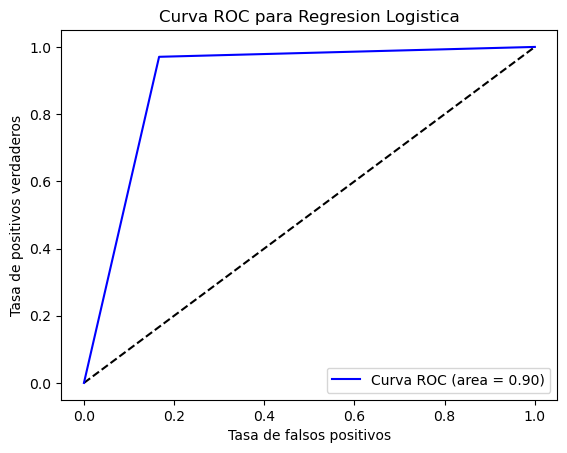

In [130]:
plt.plot([0,1], [0,1], 'k--')
plt.plot(fpr, tpr, 'b', label='Curva ROC (area = %0.2f)' %auc)
plt.ylabel('Tasa de positivos verdaderos')
plt.xlabel('Tasa de falsos positivos')
plt.legend(loc='lower right')
plt.title('Curva ROC para Regresion Logistica')